In [13]:
import pandas as pd

# Define the relative file paths 
transaction_path = '../data/raw/ieee-fraud-detection/train_transaction.csv'
identity_path = '../data/raw/ieee-fraud-detection/train_identity.csv'

print("Loading raw datasets into memory...")
df_transaction = pd.read_csv(transaction_path)
df_identity = pd.read_csv(identity_path)

print(f"Transaction Data Shape: {df_transaction.shape}")
print(f"Identity Data Shape: {df_identity.shape}")

# Check the initial memory footprint before optimization
print("\n--- Initial Memory Usage ---")
print(f"Transaction Memory: {df_transaction.memory_usage().sum() / 1024**2:.2f} MB")
print(f"Identity Memory: {df_identity.memory_usage().sum() / 1024**2:.2f} MB")

Loading raw datasets into memory...
Transaction Data Shape: (590540, 394)
Identity Data Shape: (144233, 41)

--- Initial Memory Usage ---
Transaction Memory: 1775.15 MB
Identity Memory: 45.12 MB


In [ ]:
## Optimizing memory usage

import numpy as np

def reduce_mem_usage(df):
    """ iterates through all the columns of a dataframe and modifies the data type
        to reduce memory usage.        
    """
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage of dataframe is {start_mem:.2f} MB')
    
    for col in df.columns:
        col_type = df[col].dtype
        
        # We only want to compress numeric columns, skip strings/objects
        if col_type is not object:
            c_min = df[col].min()
            c_max = df[col].max()
            
            # Handling Integer columns
            if str(col_type)[:3] == 'int':
                # np.iinfo gives the machine limits for integer types
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            
            # Handling Float columns
            elif str(col_type)[:5] == 'float':
                # np.finfo gives the machine limits for float types
                # Note: We stop at float32. Going down to float16 can cause 
                # exploding/vanishing gradients in PyTorch later.
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
                    
    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage after optimization is: {end_mem:.2f} MB')
    print(f'Decreased by {100 * (start_mem - end_mem) / start_mem:.1f}%\n')
    
    return df

In [15]:
df_transaction = reduce_mem_usage(df_transaction)
df_identity = reduce_mem_usage(df_identity)

Memory usage of dataframe is 1775.15 MB
Memory usage after optimization is: 916.30 MB
Decreased by 48.4%

Memory usage of dataframe is 45.12 MB
Memory usage after optimization is: 31.91 MB
Decreased by 29.3%



In [16]:
df_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
df_identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [18]:
df_train = pd.merge(left=df_transaction, right=df_identity, how='left', on="TransactionID")

In [20]:
print(df_train.shape)

(590540, 434)


In [28]:
df_train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,361.0,150.0,discover,142.0,...,Unknown,24.0,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,Unknown,24.0,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,Unknown,24.0,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,Unknown,24.0,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [27]:
df_train.isnull().sum()

TransactionID     0
isFraud           0
TransactionDT     0
TransactionAmt    0
ProductCD         0
                 ..
id_36             0
id_37             0
id_38             0
DeviceType        0
DeviceInfo        0
Length: 434, dtype: int64

In [ ]:
## Handling NaN values

# 1. Identify which columns are text (categorical) and which are numbers
cat_cols = df_train.select_dtypes(include=['object']).columns
num_cols = df_train.select_dtypes(exclude=['object']).columns

print(f"Found {len(cat_cols)} categorical columns and {len(num_cols)} numeric columns.")

# 2. Fill Categorical NaNs with a string
print("Imputing categorical columns...")
df_train[cat_cols] = df_train[cat_cols].fillna('Unknown')

# 3. Fill Numeric NaNs with the median of each column
print("Imputing numeric columns (this might take a minute)...")
# We calculate the median for each column and fill the NaNs in that column
df_train[num_cols] = df_train[num_cols].fillna(df_train[num_cols].median())

print("Imputation complete!")

C:\Users\User\AppData\Local\Temp\ipykernel_4132\947310305.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_train.select_dtypes(include=['object']).columns


Found 31 categorical columns and 403 numeric columns.
Imputing categorical columns...
Imputing numeric columns (this might take a minute)...
Imputation complete!


In [30]:
## Implementing Label Encoding

from sklearn.preprocessing import LabelEncoder

# Create a dictionary to store our encoders (useful later if you need to decode or encode a test set)
label_encoders = {}

print("Starting Label Encoding for categorical features...")

for col in cat_cols:
    # 1. Ensure the column is entirely strings (our 'Unknown' imputation handled most of this)
    df_train[col] = df_train[col].astype(str)
    
    # 2. Initialize the encoder for this specific column
    le = LabelEncoder()
    
    # 3. Fit the encoder (learn the unique strings) and transform the data to integers
    df_train[col] = le.fit_transform(df_train[col])
    
    # 4. Save the encoder
    label_encoders[col] = le
    
    # Downcast the new integer column to save RAM (it will default to int32/int64)
    # Since categories rarely exceed 32,000 unique values, int16 is usually safe
    if df_train[col].max() < 32767:
        df_train[col] = df_train[col].astype(np.int16)
    else:
        df_train[col] = df_train[col].astype(np.int32)

print(f"Successfully encoded {len(cat_cols)} categorical columns!")

Starting Label Encoding for categorical features...
Successfully encoded 31 categorical columns!


In [32]:
df_train[cat_cols].head()

,ProductCD,card4,card6,P_emaildomain,R_emaildomain,M1,M2,M3,M4,M5,...,id_30,id_31,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,4,2,2,0,0,1,1,1,2,0,...,41,14,260,0,2,2,2,2,0,1557
1,4,3,2,17,0,2,2,2,0,1,...,41,14,260,0,2,2,2,2,0,1557
2,4,4,3,36,0,1,1,1,0,0,...,41,14,260,0,2,2,2,2,0,1557
3,4,3,3,54,0,2,2,2,0,1,...,41,14,260,0,2,2,2,2,0,1557
4,1,3,2,17,0,2,2,2,3,2,...,7,124,164,4,1,0,1,1,2,954


In [33]:
df_train.columns

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
       'DeviceType', 'DeviceInfo'],
      dtype='str', length=434)

Plotting Class Imbalance...


C:\Users\User\AppData\Local\Temp\ipykernel_4132\3515084604.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='isFraud', data=df_train, palette='Set2')


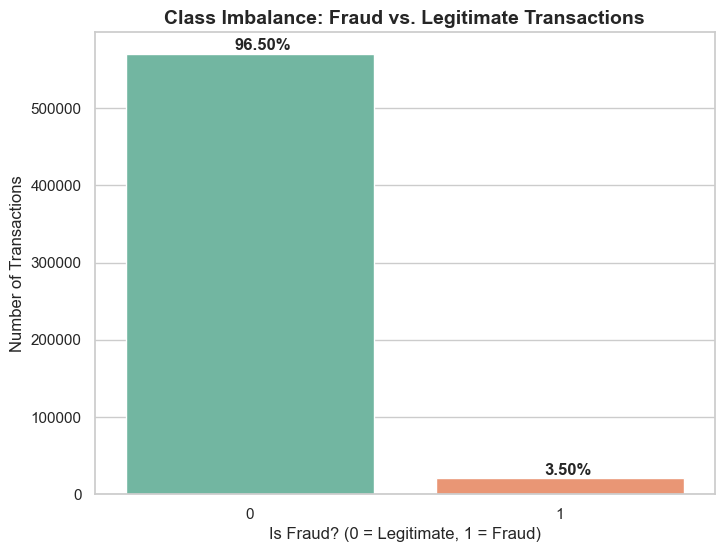

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Plotting Class Imbalance...")

# Set a clean, professional theme for the paper
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Create the count plot
ax = sns.countplot(x='isFraud', data=df_train, palette='Set2')

# Add titles and labels
plt.title('Class Imbalance: Fraud vs. Legitimate Transactions', fontsize=14, fontweight='bold')
plt.xlabel('Is Fraud? (0 = Legitimate, 1 = Fraud)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

# Calculate and annotate the percentages on top of the bars
total = len(df_train)
for p in ax.patches:
    # Calculate percentage
    percentage = f'{100 * p.get_height() / total:.2f}%'
    # Find the center of the bar for x-coordinate
    x = p.get_x() + p.get_width() / 2 - 0.05
    # Find the top of the bar for y-coordinate, add a little padding
    y = p.get_height() + 5000 
    ax.annotate(percentage, (x, y), size=12, fontweight='bold')

plt.show()

Plotting Correlation Heatmap...


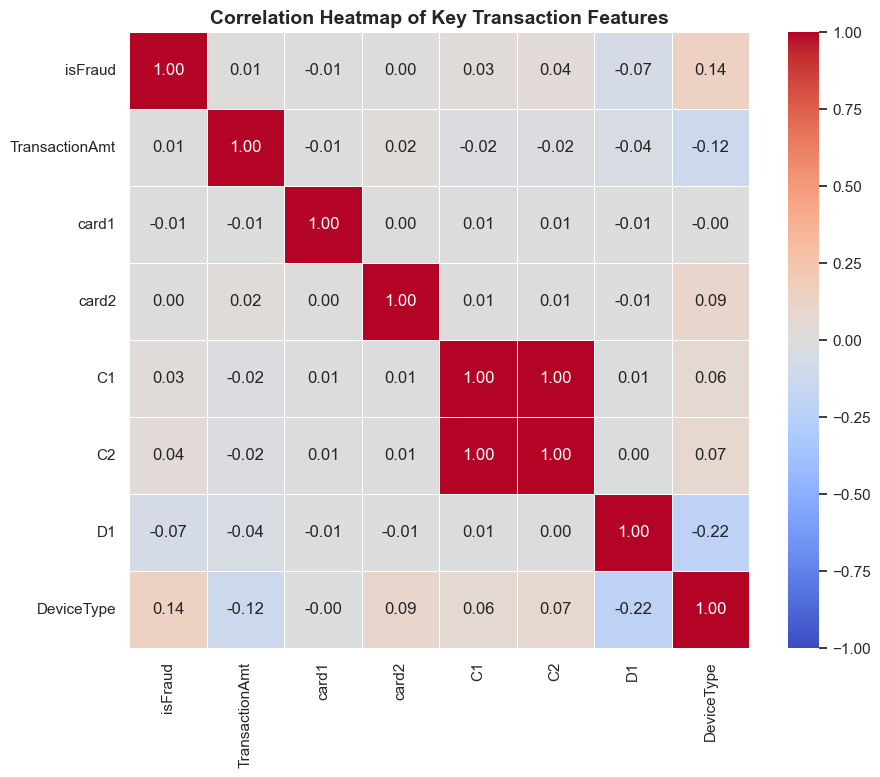

In [38]:
print("Plotting Correlation Heatmap...")

# 1. Select a targeted subset of features to keep the plot readable
subset_cols = [
    'isFraud', 'TransactionAmt', 'card1', 'card2', 
    'C1', 'C2', 'D1', 'DeviceType'
]

plt.figure(figsize=(10, 8))

# 2. Calculate the correlation matrix only for these columns
corr_matrix = df_train[subset_cols].corr()

# 3. Plot the heatmap
# annot=True puts the actual numbers in the boxes
# cmap='coolwarm' makes strong negative correlations blue and strong positive ones red
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Heatmap of Key Transaction Features', fontsize=14, fontweight='bold')
plt.show()